#Problem statement : To predict student exam scores based on study hours
[ Simple Linear Regression ]

### Importing required libraries

In [ ]:

import pandas as pd  # pandas is used for file handling / reading and writting operation in files
import numpy as np      # math calculations in python are done by using the numpy librarary
import matplotlib.pyplot as plt   #matplot.pyplot used for the visualization


#Reading Data from source

In [ ]:
from google.colab import files
uploded = files.upload()

Saving Linear regression data set.csv to Linear regression data set (1).csv


In [ ]:
# data
df = pd.read_csv("Linear regression data set.csv")
df.head() #.head() function displays first 5 rows from the dataset

,| Student_ID | Study_Hours | Exam_Score |
0,| ---------- | ----------: | ---------: |
1,| 1 | 1.0 | 35 |
2,| 2 | 1.5 | 40 |
3,| 3 | 2.0 | 42 |
4,| 4 | 2.5 | 45 |


In [ ]:
#diplays number of columns in the dataset
df.columns

Index(['| Student_ID | Study_Hours | Exam_Score |'], dtype='object')

In [ ]:
df['Study_Hours'].head()

,Study_Hours
0,1.0
1,1.5
2,2.0
3,2.5
4,3.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Student_ID   50 non-null     int64  
 1   Study_Hours  50 non-null     float64
 2   Exam_Score   50 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 1.3 KB


In [ ]:
# Convert 'Study_Hours' to int32 (note: this will truncate decimal values)
df['Study_Hours'] = df['Study_Hours'].astype("float64")

# Convert 'Exam_Score' to int32
df['Exam_Score'] = df['Exam_Score'].astype('float64')

In [ ]:
# Display updated DataFrame info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Student_ID   50 non-null     int64  
 1   Study_Hours  50 non-null     float64
 2   Exam_Score   50 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 1.3 KB


In [ ]:
df.shape

(50, 3)

## independent and dependent data :

y =   Exam_Score is dependent variable

x =  Study_Hours is an independent variable


In [ ]:
X = df[['Study_Hours']]
Y = df['Exam_Score']

In [ ]:
X.shape

(50, 1)

In [ ]:
Y.shape

(50,)

In [ ]:
# Method 1: Using .values and reshape
Y_reshaped_np = Y.values.reshape(-1, 1)
print("Shape of Y after .values.reshape():", Y_reshaped_np.shape)

Shape of Y after .values.reshape(): (50, 1)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.7, random_state=2529)

# Explicitly ensure X_train and X_test are 2D DataFrames for model fitting
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

In [ ]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((35, 1), (15, 1), (35,), (15,))

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [ ]:
Y_pred = model.predict(X_test)
print(Y_pred)

[ 84.67354416 106.80747013  91.31372195 100.16729233  93.52711454
  64.75301078  41.29104926 102.38068493  43.94712037  40.40569222
  53.6860478   42.61908481  66.96640338  51.4726552   57.22747595]


In [ ]:
pred1 = model.predict([[8]])
pred1

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([71.39318857])

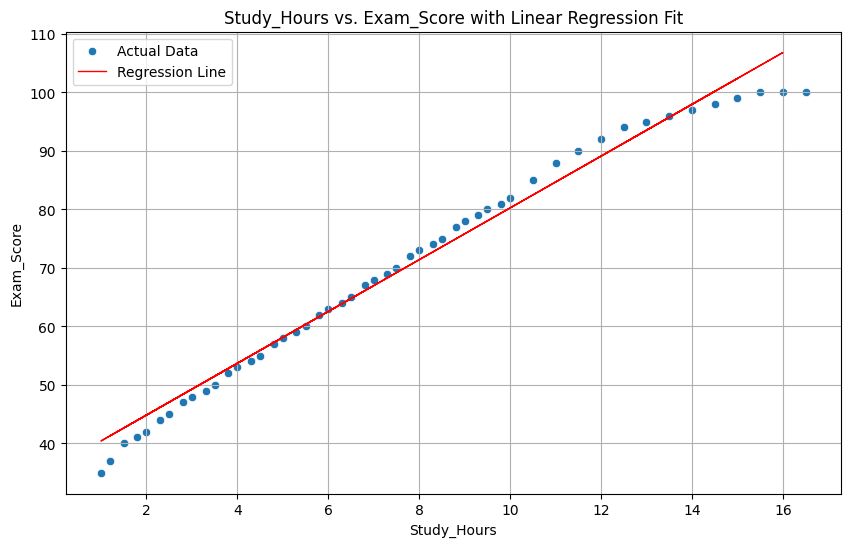

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Study_Hours', y='Exam_Score', data=df, label='Actual Data')
plt.plot(X_test, Y_pred, color='red', linewidth=1, label='Regression Line')
plt.xlabel('Study_Hours')
plt.ylabel('Exam_Score')
plt.title('Study_Hours vs. Exam_Score with Linear Regression Fit')
plt.legend()
plt.grid(True)
plt.show()

## Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate R-squared
r_squared = r2_score(Y_test, Y_pred)
print(f'R-squared: {r_squared:.4f}')

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(Y_test, Y_pred)
print(f'Mean Absolute Error (MAE): {mae:.2f}')

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(Y_test, Y_pred)
print(f'Mean Squared Error (MSE): {mse:.2f}')

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

R-squared: 0.9832
Mean Absolute Error (MAE): 2.58
Mean Squared Error (MSE): 9.99
Root Mean Squared Error (RMSE): 3.16


In [ ]:
accuracy_score = model.score(X_test, Y_test)
print("Accuracy Score:", accuracy_score)

Accuracy Score: 0.9832155387677748
